# Understanding Complex Demodulation Plots

**Complex demodulation** is a technique for analysing time series where the **amplitude and/or phase** of a periodic component change over time. Unlike the ACF and spectral plot (which assume stationarity), complex demodulation tracks how a known periodic component evolves across the series.

**The idea:** Multiply the time series by a complex exponential at the target frequency f₀:

```
z(t) = y(t) · e^(-2πi·f₀·t) = y(t) · [cos(2πf₀t) − i·sin(2πf₀t)]
```

Then low-pass filter z(t) to get the **complex envelope**. Its magnitude is the **amplitude modulation** (how the amplitude of the f₀ component changes over time) and its argument is the **phase modulation** (how the phase shifts over time).

Two demodulation plots are used:
1. **Complex Demodulation Amplitude Plot** — amplitude of the target frequency component vs time
2. **Complex Demodulation Phase Plot** — phase of the target frequency component vs time

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sig
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

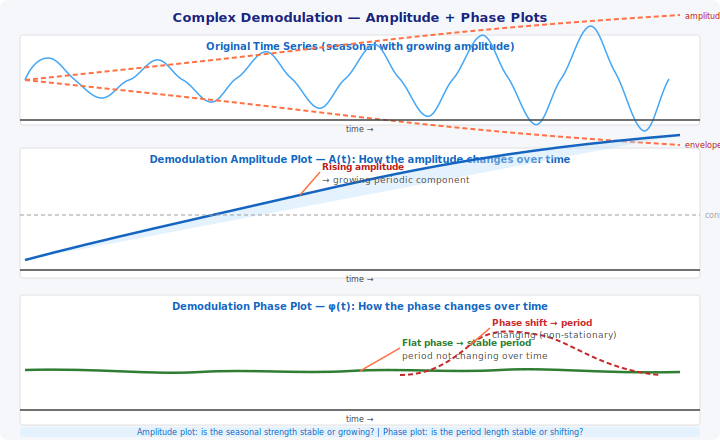

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="13" font-weight="bold"
        fill="#1A237E">Complex Demodulation — Amplitude + Phase Plots</text>

  <!-- ── TOP: Original signal with amplitude modulation ── -->
  <rect x="20" y="35" width="680" height="90" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="360" y="50" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Original Time Series (seasonal with growing amplitude)</text>
  <!-- Sine wave with growing amplitude -->
  <path d="M 25,80 C 30,68 38,58 48,58 C 58,58 65,72 75,80 C 85,88 92,98 102,98 C 112,98 119,83 129,80
           C 139,77 146,62 156,60 C 166,58 173,75 183,80 C 193,85 200,100 210,102 C 220,104 227,84 237,78
           C 247,72 254,55 264,52 C 274,49 281,70 291,78 C 301,86 308,105 318,108 C 328,111 335,87 345,79
           C 355,71 362,50 372,45 C 382,40 389,68 399,78 C 409,88 416,112 426,116 C 436,120 443,90 453,79
           C 463,68 470,42 480,36 C 490,30 497,62 507,76 C 517,90 524,118 534,124 C 544,130 551,93 561,79
           C 571,65 578,34 588,27 C 598,20 605,55 615,72 C 625,89 632,122 642,130 C 652,138 659,95 669,79 680,68"
        fill="none" stroke="#42A5F5" stroke-width="1.5"/>
  <!-- Envelope lines (amplitude) -->
  <path d="M 25,80 C 100,72 200,62 300,50 C 400,38 500,26 680,15"
        fill="none" stroke="#FF7043" stroke-width="2" stroke-dasharray="5,3"/>
  <path d="M 25,80 C 100,88 200,98 300,110 C 400,122 500,134 680,145"
        fill="none" stroke="#FF7043" stroke-width="2" stroke-dasharray="5,3"/>
  <text x="685" y="19" font-size="8" fill="#B71C1C">amplitude</text>
  <text x="685" y="148" font-size="8" fill="#B71C1C">envelope</text>
  <line x1="20" y1="120" x2="700" y2="120" stroke="#424242" stroke-width="1.5"/>
  <text x="360" y="132" text-anchor="middle" font-size="8" fill="#424242">time →</text>

  <!-- ── MIDDLE: Amplitude plot ── -->
  <rect x="20" y="148" width="680" height="130" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="360" y="163" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Demodulation Amplitude Plot — A(t): How the amplitude changes over time</text>
  <!-- Rising amplitude curve -->
  <path d="M 25,260 C 100,240 200,218 300,195 C 400,172 500,150 680,135"
        fill="#BBDEFB" opacity="0.4"/>
  <path d="M 25,260 C 100,240 200,218 300,195 C 400,172 500,150 680,135"
        fill="none" stroke="#1565C0" stroke-width="2.5"/>
  <!-- Constant line for reference -->
  <line x1="20" y1="215" x2="700" y2="215" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="705" y="218" font-size="8" fill="#9E9E9E">constant A</text>
  <!-- Rising annotation -->
  <line x1="300" y1="195" x2="320" y2="172" stroke="#FF7043" stroke-width="1.5"/>
  <text x="322" y="170" font-size="9" font-weight="bold" fill="#B71C1C">Rising amplitude</text>
  <text x="322" y="183" font-size="9" fill="#555">→ growing periodic component</text>
  <line x1="20" y1="270" x2="700" y2="270" stroke="#424242" stroke-width="1.5"/>
  <text x="360" y="282" text-anchor="middle" font-size="8" fill="#424242">time →</text>

  <!-- ── BOTTOM: Phase plot ── -->
  <rect x="20" y="295" width="680" height="130" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="360" y="310" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Demodulation Phase Plot — φ(t): How the phase changes over time</text>
  <!-- Constant (stationary) phase -->
  <path d="M 25,370 C 100,368 150,375 200,372 C 250,369 300,374 350,371
           C 400,368 450,373 500,370 C 550,367 600,374 680,372"
        fill="none" stroke="#2E7D32" stroke-width="2.5"/>
  <!-- Annotation: constant phase = stable periodicity -->
  <line x1="360" y1="371" x2="400" y2="348" stroke="#FF7043" stroke-width="1.5"/>
  <text x="402" y="346" font-size="9" font-weight="bold" fill="#2E7D32">Flat phase → stable period</text>
  <text x="402" y="359" font-size="9" fill="#555">period not changing over time</text>
  <!-- Phase shift example (dashed, red) -->
  <path d="M 400,375 C 430,375 450,362 470,345 C 490,328 510,330 540,335 C 570,340 600,370 660,375"
        fill="none" stroke="#C62828" stroke-width="2" stroke-dasharray="5,3"/>
  <line x1="470" y1="345" x2="490" y2="328" stroke="#FF7043" stroke-width="1.5"/>
  <text x="492" y="326" font-size="9" font-weight="bold" fill="#C62828">Phase shift → period</text>
  <text x="492" y="338" font-size="9" fill="#555">changing (non-stationary)</text>
  <line x1="20" y1="410" x2="700" y2="410" stroke="#424242" stroke-width="1.5"/>
  <text x="360" y="422" text-anchor="middle" font-size="8" fill="#424242">time →</text>

  <!-- Takeaway -->
  <rect x="20" y="427" width="680" height="10" fill="#E3F2FD" rx="3"/>
  <text x="360" y="435" text-anchor="middle" font-size="8" fill="#1565C0">
    Amplitude plot: is the seasonal strength stable or growing?   |   Phase plot: is the period length stable or shifting?
  </text>
</svg>
"""
display(SVG(_svg))

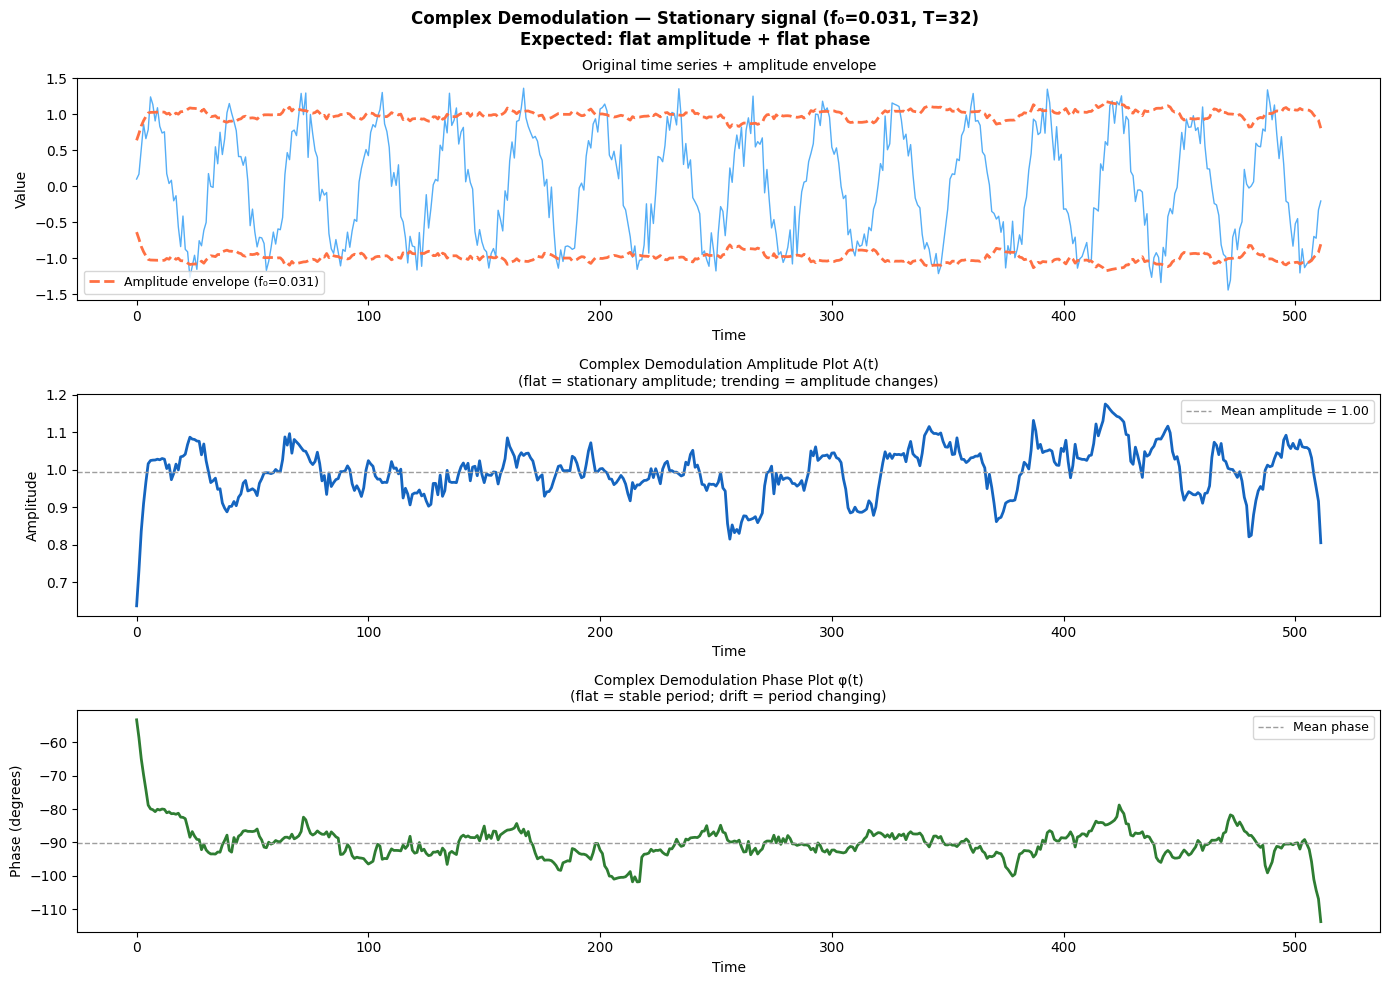

In [3]:
def complex_demodulation(y, f0, fs=1.0, smoothing_window=None, title="Complex Demodulation"):
    """
    Complex demodulation at target frequency f0.
    Returns amplitude and phase envelope over time.
    """
    n = len(y)
    t = np.arange(n) / fs

    # Multiply by complex exponential at f0
    z = y * np.exp(-2j * np.pi * f0 * np.arange(n))

    # Low-pass filter (moving average or Gaussian smooth)
    w = smoothing_window or max(5, int(1/(2*f0)))
    kernel = np.ones(w) / w
    re_smooth = np.convolve(z.real, kernel, mode='same')
    im_smooth = np.convolve(z.imag, kernel, mode='same')
    envelope = re_smooth + 1j * im_smooth

    amplitude = np.abs(envelope) * 2  # factor 2 for one-sided
    phase = np.angle(envelope)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    # Original signal
    axes[0].plot(t, y, color='#42A5F5', linewidth=1, alpha=0.9)
    axes[0].plot(t, amplitude, color='#FF7043', linewidth=2, linestyle='--', label=f'Amplitude envelope (f₀={f0:.3f})')
    axes[0].plot(t, -amplitude, color='#FF7043', linewidth=2, linestyle='--')
    axes[0].set_title('Original time series + amplitude envelope', fontsize=10)
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Value')
    axes[0].legend(fontsize=9)

    # Amplitude plot
    axes[1].plot(t, amplitude, color='#1565C0', linewidth=2)
    axes[1].axhline(amplitude.mean(), color='#9E9E9E', linewidth=1, linestyle='--',
                    label=f'Mean amplitude = {amplitude.mean():.2f}')
    axes[1].set_title('Complex Demodulation Amplitude Plot A(t)\n(flat = stationary amplitude; trending = amplitude changes)', fontsize=10)
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend(fontsize=9)

    # Phase plot
    axes[2].plot(t, np.degrees(phase), color='#2E7D32', linewidth=2)
    axes[2].axhline(np.degrees(phase).mean(), color='#9E9E9E', linewidth=1, linestyle='--', label='Mean phase')
    axes[2].set_title('Complex Demodulation Phase Plot φ(t)\n(flat = stable period; drift = period changing)', fontsize=10)
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Phase (degrees)')
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return amplitude, phase

np.random.seed(42)
n = 512
t = np.arange(n)
f0 = 1/32  # target frequency (period = 32)

# Case 1: Stationary — constant amplitude, constant phase
y_stationary = np.sin(2*np.pi*f0*t) + 0.2*np.random.normal(0, 1, n)
amplitude1, phase1 = complex_demodulation(y_stationary, f0=f0,
    title=f"Complex Demodulation — Stationary signal (f₀={f0:.3f}, T=32)\nExpected: flat amplitude + flat phase")

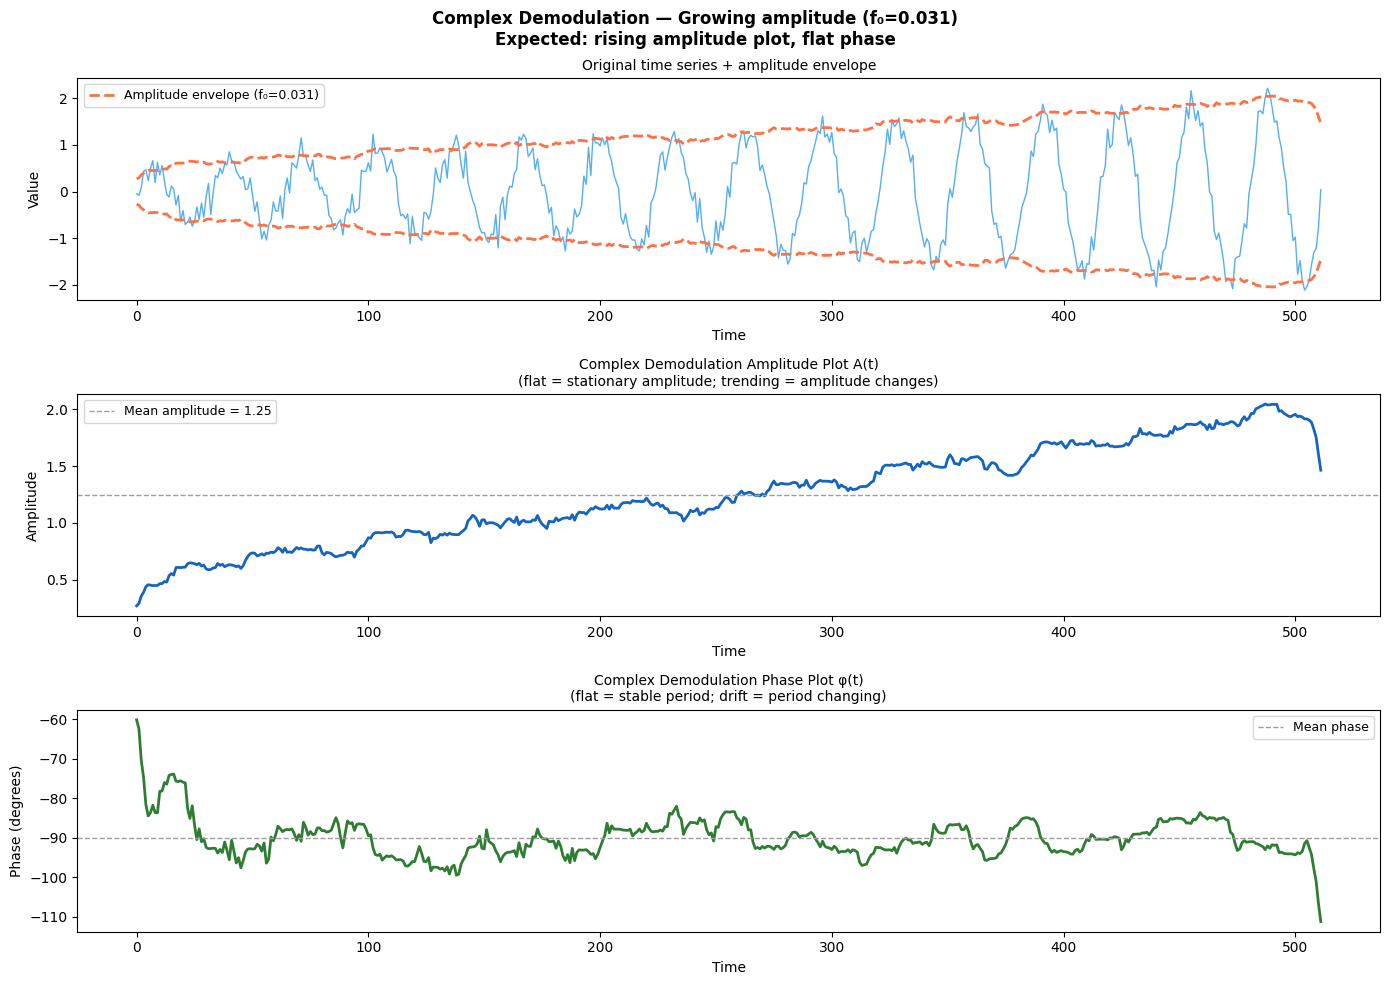

In [4]:
# Case 2: Amplitude-modulated — seasonal strength increases over time
ramp = np.linspace(0.5, 2.0, n)
y_am = ramp * np.sin(2*np.pi*f0*t) + 0.2*np.random.normal(0, 1, n)
amplitude2, phase2 = complex_demodulation(y_am, f0=f0,
    title=f"Complex Demodulation — Growing amplitude (f₀={f0:.3f})\nExpected: rising amplitude plot, flat phase")

## Key Takeaways

| | |
|---|---|
| **Purpose** | Diagnose whether a periodic component's amplitude or period is stable over time |
| **Amplitude plot** | Flat → stationary seasonal amplitude; trending → amplitude changes over time |
| **Phase plot** | Flat → stable period; drifting → period is shifting (non-stationary seasonality) |
| **f₀** | Target frequency — must be identified first (from spectral plot or domain knowledge) |
| **Low-pass filter** | Smoothing window should span 2–3 full periods of f₀ |
| **Rising amplitude** | Seasonal component is growing — multiplicative decomposition may be appropriate |
| **Phase drift** | Period is not constant — SARIMA or seasonal adjustment may fail |
| **vs spectral plot** | Spectral plot: average power over entire series; demodulation: tracks evolution over time |
| **Application** | Economic seasonality, climate cycles, industrial vibration monitoring |